In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*.npz'))
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/*/*.npz'))
print(sm_files)
sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*.npz'))
data_sm_exp = []
data_qq_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        
for f in  sm_qq_files:
    aux = np.load(f, allow_pickle = True)
    data_qq_sm_exp.append(aux)

data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])
print(data_sm_exp[0]['process'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_2/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_1/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_8/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_7/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_5/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_6/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_3/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_4/mPsiT_0_mSDM_0.npz']
$p

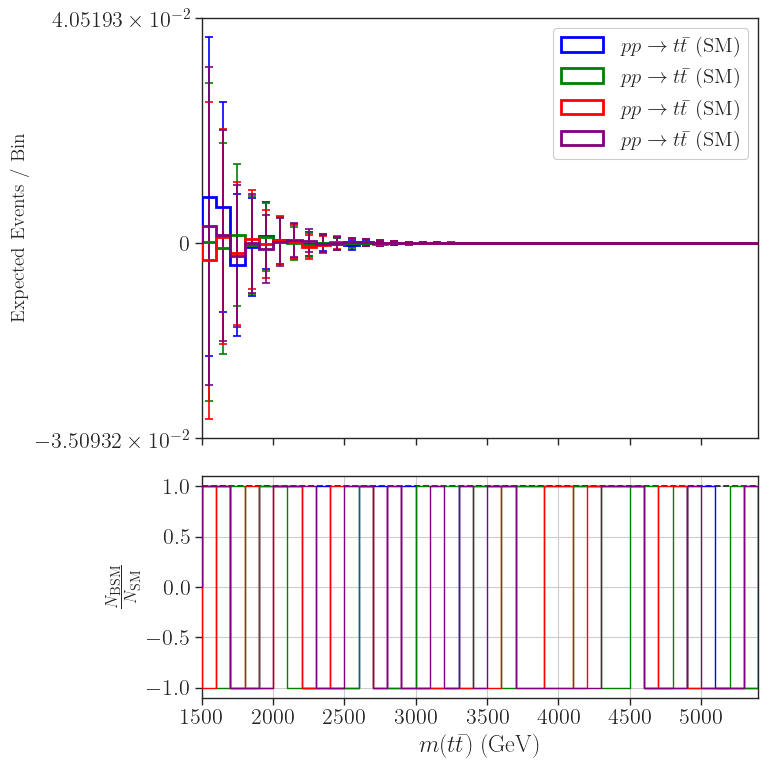

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

bins = np.arange(1500., 5500., 100.)

################
# SM err (%)   #
################

lum = 1e-03 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)
pmodels = []

# Expanded color list to handle more models automatically
bsm_colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
bsm_hists, bsm_errs, bsm_labels = [], [], []

# --- Setup and Binning ---
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for j in range(0, len(data_sm_exp)-1, 2):

    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    process = r'$p p \to t \bar{t}$'
    model = d['model']
    model_raw = d['model']
    model_name = str(np.atleast_1d(model_raw)[0])
    display_name = model_name
    pmodels.append(r'%s (%s)' % (process, display_name))
    label = pmodels[-1]

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    # Scale by luminosity!
    h_bsm_total = (h1 - h2)  * lum_scale
    hErr_bsm_total_sq = (hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2)

    integral_bsm = np.sum(h_bsm_total)
    h_bsm = h_bsm_total
    
    # hErr_bsm is already the square root of the variance
    hErr_bsm = np.sqrt(hErr_bsm_total_sq)

    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(label)

    # Calculate safe color index using modulo
    c_idx = int(j/2) % len(bsm_colors)
    current_color = bsm_colors[c_idx]

    axarr[0].hist(
        bins[:-1], weights=h_bsm, label=label, bins=bins,
        color=current_color, alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, h_bsm, yerr=hErr_bsm, color=current_color, 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )
    
    # Suppress divide-by-zero warnings in ratio plot
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_weights = np.where(h_bsm != 0, np.abs(h_bsm)/h_bsm, 0)
        
    axarr[1].hist(
        bins[:-1], weights=ratio_weights, label=label, bins=bins,
        color=current_color, alpha=1.0, histtype='step', 
        linewidth=1, fill=False, zorder=3
    )

# Upper plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_yscale('symlog', linthresh = 0.1)

# CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
axarr[0].set_xlim(bins.min(), bins.max())

# Bottom plot
axarr[1].axhline(y=1, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)

minor_tick_locations = np.concatenate((
    np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
    np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
))
axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

plt.tight_layout()
#plt.savefig('Dists_comparison_interference.png')
plt.show()

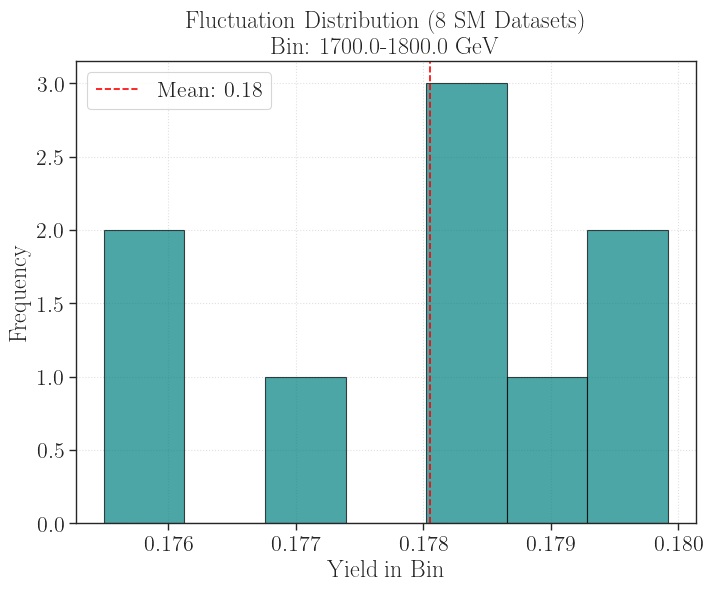

Values obtained from the 8 datasets: [np.float64(0.1754948487102297), np.float64(0.17947450544852472), np.float64(0.17991720625684593), np.float64(0.1784803787470537), np.float64(0.1773786546420979), np.float64(0.17925523176626257), np.float64(0.17605629207025686), np.float64(0.1783439798145423), np.float64(0.17804623837906774)]
Mean of bin yields: 0.1780
Standard Deviation (MC Noise): 0.0014
--- Poisson Statistical Test ---
Mean (μ):      0.1780
Variance (σ²): 0.0000
Fano Factor:   0.0000
Result: Data is Under-dispersed.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bin_distribution(data_sm_exp, target_bin_idx, lum=1e-03):
    """
    Computes the distribution of a single bin across all 8 independent SM datasets.
    """
    lum_scale = lum * 1000.0
    bin_values = []
    
    # 1. Iterate through all 8 datasets to collect the yield for the target bin
    bins = np.arange(1500., 5500., 100.)
    
    for d in data_sm_exp:
        # Calculate yield in the target bin
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        
        # Scale by luminosity and store only the value of the target bin
        bin_value = h[target_bin_idx] * lum_scale
        bin_values.append(bin_value)
    
    # 2. Plotting the distribution of the 8 values
    plt.figure(figsize=(8, 6))
    
    # Using 'bins=5' for the histogram of 8 values is usually a good starting point
    plt.hist(bin_values, bins=7, color='teal', alpha=0.7, edgecolor='black')
    
    # Add a vertical line for the mean of these 8 datasets
    plt.axvline(np.mean(bin_values), color='red', linestyle='--', label=f'Mean: {np.mean(bin_values):.2f}')
    
    plt.title(f"Fluctuation Distribution (8 SM Datasets)\nBin: {bins[target_bin_idx]}-{bins[target_bin_idx+1]} GeV")
    plt.xlabel("Yield in Bin")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    # 3. Print stats to verify the variance
    print(f"Values obtained from the 8 datasets: {bin_values}")
    print(f"Mean of bin yields: {np.mean(bin_values):.4f}")
    print(f"Standard Deviation (MC Noise): {np.std(bin_values):.4f}")

    return bin_values
# Example: target bin index 2 corresponds to 1700-1800 GeV
bin_values = plot_bin_distribution(data_sm_exp, target_bin_idx=2, lum=1e-03)
import numpy as np
import scipy.stats as stats

def test_poisson_nature(bin_values):
    """
    Tests if the distribution of bin yields is Poissonian 
    by comparing the Mean and Variance.
    """
    mu = np.mean(bin_values)
    var = np.var(bin_values, ddof=1)
    fano_factor = var / mu if mu > 0 else 0
    
    print(f"--- Poisson Statistical Test ---")
    print(f"Mean (μ):      {mu:.4f}")
    print(f"Variance (σ²): {var:.4f}")
    print(f"Fano Factor:   {fano_factor:.4f}")
    
    if np.isclose(fano_factor, 1.0, atol=0.2):
        print("Result: Data is approximately Poissonian.")
    elif fano_factor > 1.0:
        print("Result: Data is Over-dispersed (Fluctuations > Poisson).")
    else:
        print("Result: Data is Under-dispersed.")
        
    # Optional: Perform a Chi-Square test against a Poisson distribution
    # Note: With only 8 samples, this has low statistical power
    # k = np.round(bin_values)
    # print(f"Chi-Square test p-value: {stats.chisquare(f_obs=k, f_exp=[mu]*len(k))[1]:.4f}")

# Re-using the bin_values from the previous step
test_poisson_nature(bin_values)

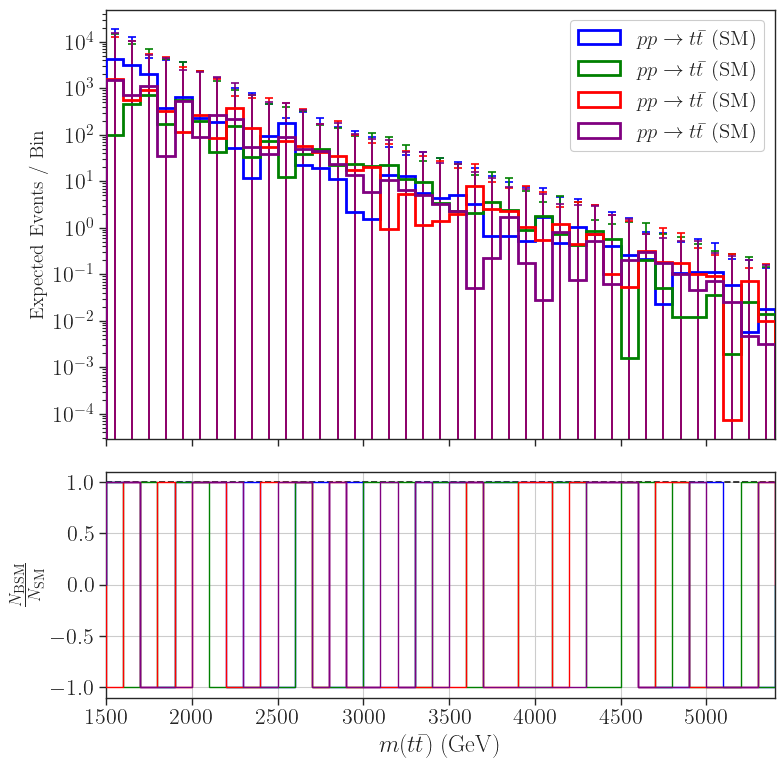

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

bins = np.arange(1500., 5500., 100.)

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)
pmodels = []

# Expanded color list to handle more models automatically
bsm_colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
bsm_hists, bsm_errs, bsm_labels = [], [], []

# --- Setup and Binning ---
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for j in range(0, len(data_sm_exp)-1, 2):

    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    process = r'$p p \to t \bar{t}$'
    model = d['model']
    model_raw = d['model']
    model_name = str(np.atleast_1d(model_raw)[0])
    display_name = model_name
    pmodels.append(r'%s (%s)' % (process, display_name))
    label = pmodels[-1]

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    # Scale by luminosity!
    h_bsm_total = (h1 - h2)  * lum_scale
    hErr_bsm_total_sq = (hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2)

    integral_bsm = np.sum(h_bsm_total)
    h_bsm = h_bsm_total
    
    # hErr_bsm is already the square root of the variance
    hErr_bsm = np.sqrt(hErr_bsm_total_sq)

    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(label)

    # Calculate safe color index using modulo
    c_idx = int(j/2) % len(bsm_colors)
    current_color = bsm_colors[c_idx]

    axarr[0].hist(
        bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
        color=current_color, alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, h_bsm, yerr=hErr_bsm, color=current_color, 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )
    
    # Suppress divide-by-zero warnings in ratio plot
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_weights = np.where(h_bsm != 0, np.abs(h_bsm)/h_bsm, 0)
        
    axarr[1].hist(
        bins[:-1], weights=ratio_weights, label=label, bins=bins,
        color=current_color, alpha=1.0, histtype='step', 
        linewidth=1, fill=False, zorder=3
    )

# Upper plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_yscale('log')

# CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
axarr[0].set_xlim(bins.min(), bins.max())

# Bottom plot
axarr[1].axhline(y=1, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)

minor_tick_locations = np.concatenate((
    np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
    np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
))
axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

plt.tight_layout()
#plt.savefig('Dists_comparison_interference.png')
plt.show()

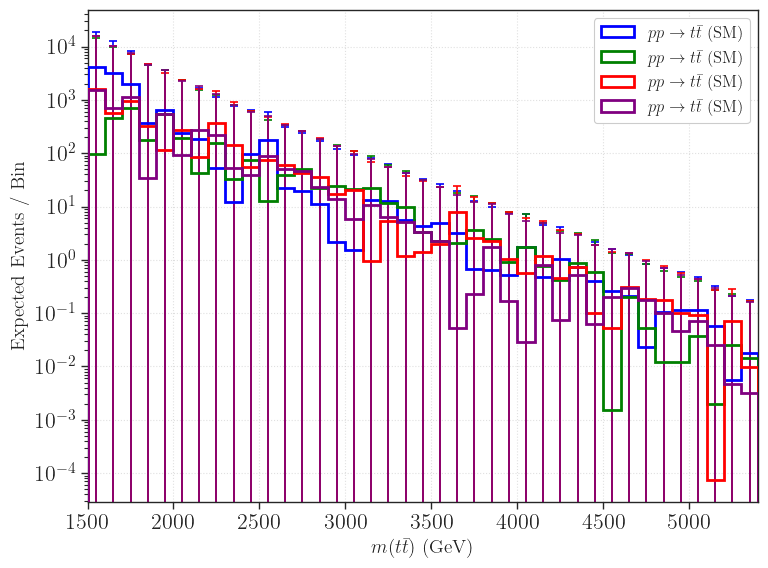

In [21]:


bins = np.arange(1500., 5500., 100.)
lum = 500  # fb^-1
lum_scale = lum * 1000.0 
sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0
bsm_colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
    

# --- Setup: Single Figure and Axis ---
fig, ax = plt.subplots(figsize=(8, 6))

for j in range(0, len(data_sm_exp) - 1, 2):
    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    model_name = str(np.atleast_1d(d['model'])[0])
    label = rf'$p p \to t \bar{{t}} $ ({model_name})'

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    # Calculation
    h_bsm = (h1 - h2) * lum_scale
    hErr_bsm = np.sqrt((hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2))

    # Plotting
    c_idx = int(j/2) % len(bsm_colors)
    current_color = bsm_colors[c_idx]

    ax.hist(
        bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
        color=current_color, alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    ax.errorbar(
        x, np.abs(h_bsm), yerr=hErr_bsm, color=current_color, 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

# Formatting
ax.legend(framealpha=1.0, loc='upper right', fontsize=12)
ax.set_yscale('log')
ax.set_ylabel(r'Expected Events / Bin', fontsize=14)
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_xlim(bins.min(), bins.max())
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

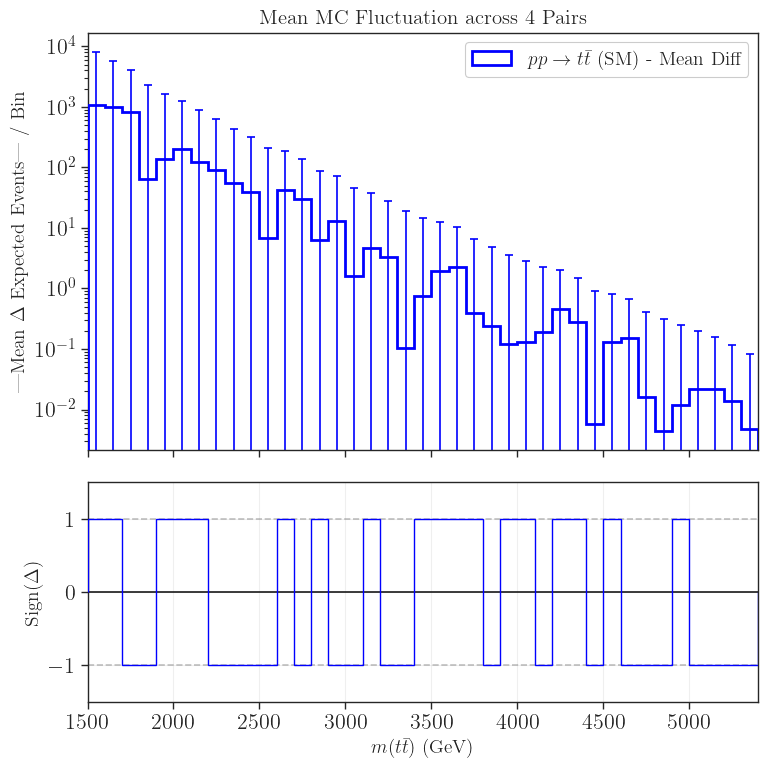

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

bins = np.arange(1500., 5500., 100.)

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)

# --- Accumulators for the Mean ---
n_bins = len(bins) - 1
sum_diff = np.zeros(n_bins)
sum_var = np.zeros(n_bins)
pair_count = 0

# --- Setup and Binning ---
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.15, bottom=0.12, right=0.95, top=0.95, hspace=0.1)

# Loop to accumulate the differences and variances
for j in range(0, len(data_sm_exp)-1, 2):

    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    # Extract model name for the legend (assuming all pairs are the same model)
    if pair_count == 0:
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        label = r'$p p \to t \bar{t}$ (%s) - Mean Diff' % model_name

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    # Calculate scaled difference and variance for this specific pair
    diff = (h1 - h2) * lum_scale
    var = (hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2)

    # Accumulate
    sum_diff += diff
    sum_var += var
    pair_count += 1

# --- Calculate the Mean and Error ---
mean_diff = sum_diff / pair_count
mean_err = np.sqrt(sum_var) / pair_count # Standard error of the mean

# --- Plotting the Mean ---
# Plot the absolute value of the mean difference as a step histogram
axarr[0].hist(
    bins[:-1], weights=np.abs(mean_diff), label=label, bins=bins,
    color='blue', alpha=1.0, histtype='step', 
    linewidth=2, fill=False, zorder=3
)

# Plot the error bars
axarr[0].errorbar(
    x, np.abs(mean_diff), yerr=mean_err, color='blue', 
    fmt='none', capsize=3, capthick=1.2, barsabove=True
)

# Suppress divide-by-zero warnings in ratio/sign plot
with np.errstate(divide='ignore', invalid='ignore'):
    # This plots +1 if the mean diff is positive, -1 if negative, 0 if 0
    ratio_weights = np.where(mean_diff != 0, np.abs(mean_diff)/mean_diff, 0)
    
axarr[1].hist(
    bins[:-1], weights=ratio_weights, bins=bins,
    color='blue', alpha=1.0, histtype='step', 
    linewidth=1, fill=False, zorder=3
)

# --- Formatting ---
# Upper plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=14)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'|Mean $\Delta$ Expected Events| / Bin', fontsize=14)
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_title("Mean MC Fluctuation across {} Pairs".format(pair_count), fontsize=15)

# Bottom plot
axarr[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axarr[1].axhline(y=-1, color='gray', linestyle='--', alpha=0.5)
axarr[1].axhline(y=0, color='k', linestyle='-')
axarr[1].set_ylabel(r'Sign$(\Delta)$', fontsize=14)
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
axarr[1].grid(True, alpha=0.3)
axarr[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
#plt.savefig('Mean_Dists_comparison_interference.png')
plt.show()

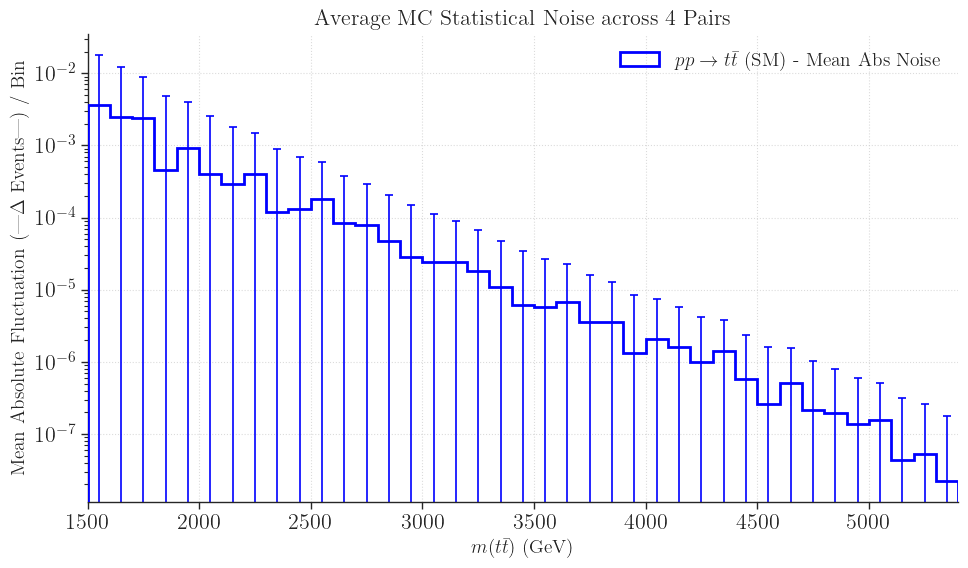

In [10]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(1500., 5500., 100.)

################
# SM err (%)   #
################

lum = 1e-3 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

x = (bins[:-1] + bins[1:]) / 2.0

# --- Accumulators for the Mean Absolute Difference ---
n_bins = len(bins) - 1
sum_abs_diff = np.zeros(n_bins)
sum_var = np.zeros(n_bins)
pair_count = 0

# --- Setup Single Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Loop to accumulate the absolute differences and variances
for j in range(0, len(data_sm_exp)-1, 2):

    d = data_sm_exp[j]
    d_next = data_sm_exp[j+1]

    # Extract model name for the legend
    if pair_count == 0:
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        label = r'$p p \to t \bar{t}$ (%s) - Mean Abs Noise' % model_name

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    # Calculate the ABSOLUTE scaled difference so fluctuations don't cancel!
    abs_diff = np.abs(h1 - h2) * lum_scale
    var = (hErr1_sq + hErr2_sq + (sm_err*h1)**2 + (sm_err*h2)**2) * (lum_scale**2)

    # Accumulate
    sum_abs_diff += abs_diff
    sum_var += var
    pair_count += 1

# --- Calculate the Mean and Error ---
mean_abs_diff = sum_abs_diff / pair_count
mean_err = np.sqrt(sum_var) / pair_count # Standard error of the mean

# --- Plotting ---
# Plot the mean absolute difference as a step histogram
ax.hist(
    bins[:-1], weights=mean_abs_diff, label=label, bins=bins,
    color='blue', alpha=1.0, histtype='step', 
    linewidth=2, fill=False, zorder=3
)

# Plot the error bars
ax.errorbar(
    x, mean_abs_diff, yerr=mean_err, color='blue', 
    fmt='none', capsize=3, capthick=1.2, barsabove=True
)

# --- Formatting ---
ax.legend(frameon=False, loc='upper right', fontsize=14)
ax.set_yscale('log')
ax.set_ylabel(r'Mean Absolute Fluctuation (|$\Delta$ Events|) / Bin', fontsize=14)
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_xlim(bins.min(), bins.max())
ax.set_title(f"Average MC Statistical Noise across {pair_count} Pairs", fontsize=16)

# Clean up grid and spines
ax.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('Mean_Abs_Fluctuation.pdf', bbox_inches='tight')
plt.show()